Principal Axes:
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]

Explained Variance:
[2.93808505 0.9201649 ]

Singular Values:
[20.99315978 11.7483929 ]


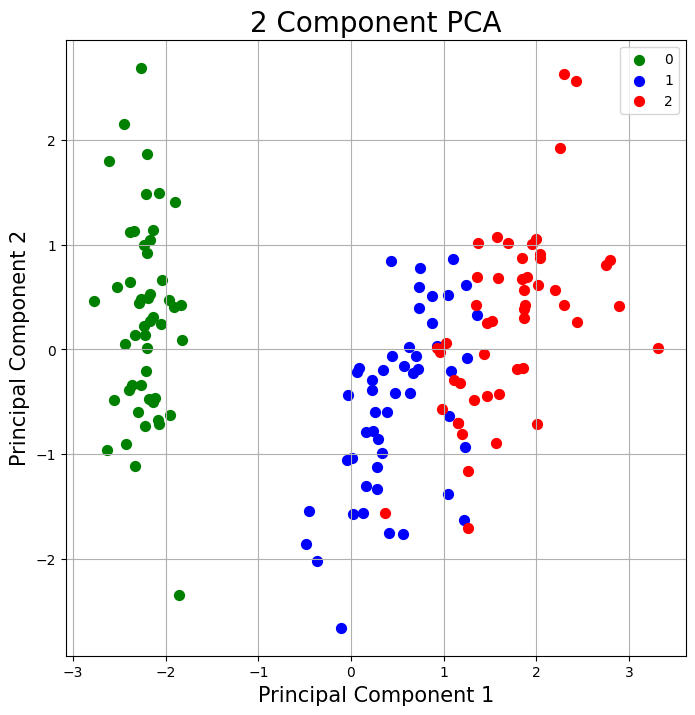

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = datasets.load_iris()
X = iris.data
y = iris.target


X_std = StandardScaler().fit_transform(X)


pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X_std)

principal_axes = pca.components_
explained_variance = pca.explained_variance_
singular_values = np.sqrt(explained_variance * X.shape[0])

print("Principal Axes:")
print(principal_axes)
print("\nExplained Variance:")
print(explained_variance)
print("\nSingular Values:")
print(singular_values)


principalDf = pd.DataFrame(data=principalComponents, columns=['principal component 1', 'principal component 2'])
finalDf = pd.concat([principalDf, pd.DataFrame(iris.target, columns=['target'])], axis=1)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('Principal Component 1', fontsize=15)
ax.set_ylabel('Principal Component 2', fontsize=15)
ax.set_title('2 Component PCA', fontsize=20)
targets = [0, 1, 2]
colors = ['g', 'b', 'r']
for target, color in zip(targets, colors):
    indicesToKeep = finalDf['target'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1'],
               finalDf.loc[indicesToKeep, 'principal component 2'],
               c=color, s=50)
ax.legend(targets)
ax.grid()
plt.show()